### 패키지 및 데이터

In [35]:
# ==================================================
# 기본 라이브러리
# ==================================================
import numpy as np
import seaborn as sb

from matplotlib import pyplot as plt
from pandas import DataFrame, concat


# ==================================================
# scikit-learn
# ==================================================
from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    learning_curve,
)

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier


# ==================================================
# 평가 지표
# ==================================================
from sklearn.metrics import (
    # log_loss,  # 다중분류 함수에서는 사용하지 않음
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
)


# ==================================================
# 사용자 정의 라이브러리
# ==================================================
from hossam import *


### 데이터

In [3]:
origin = load_data("iris")
origin.info()

1936년 영국의 통계학자 로널드 피셔(Ronald A. Fisher)가 소개한 3가지 품종(setosa, versicolor, virginica)의 붓꽃(Iris)에 대한 꽃받침과 꽃잎의 길이와 너비 측정값으로 구성된 유명한 머신러닝 및 데이터 분석용 데이터셋.(출처: Kaggle)

field         description
------------  -------------
Sepal.Length  꽃밭침 길이
Sepal.Width   꽃밭침 너비
Petal.Length  꽃잎 길이
Petal.Width   꽃잎 너비
Species       품종

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.Length  150 non-null    float64
 1   Sepal.Width   150 non-null    float64
 2   Petal.Length  150 non-null    float64
 3   Petal.Width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


# 데이터 기본 처리

### 종속 변수의 타입 변환

In [12]:
df1 = origin.copy()
df1['Species'] = df1['Species'].astype('category')
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Sepal.Length  150 non-null    float64 
 1   Sepal.Width   150 non-null    float64 
 2   Petal.Length  150 non-null    float64 
 3   Petal.Width   150 non-null    float64 
 4   Species       150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB


### 종속변수 종류 확인

In [13]:
df1['Species'].unique()

['setosa', 'versicolor', 'virginica']
Categories (3, object): ['setosa', 'versicolor', 'virginica']

### 종속변수 라벨링

In [14]:
map_dict = {}

for i,v in enumerate(df1['Species'].unique()):
    map_dict[v] = i

map_dict
df1.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.100,3.500,1.400,0.200,setosa
1,4.900,3.000,1.400,0.200,setosa
2,4.700,3.200,1.300,0.200,setosa
3,4.600,3.100,1.500,0.200,setosa
4,5.000,3.600,1.400,0.200,setosa


In [23]:
df2 = df1.copy()
df2['Species'] = df2['Species'].map(map_dict)
df2['Species'].unique()

[0, 1, 2]
Categories (3, int64): [0, 1, 2]

### 데이터 분할

In [27]:

yname = "Species"
X = df2.drop(columns=[yname])
y = df2[yname]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.25, random_state=52)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((112, 4), (38, 4), (112,), (38,))

In [40]:
from sklearn.metrics import log_loss

### 함수 정의

In [41]:
def hs_cls_bin_scores(estimator, X_test, y_test):
    # ===============================
    # 예측값 / 확률
    # ===============================
    y_pred_proba = estimator.predict_proba(X_test)[:, 1]
    y_pred = estimator.predict(X_test)

    # ===============================
    # McFadden pseudo R²
    # ===============================
    log_loss_test = -log_loss(y_test, y_pred_proba, normalize=False)

    y_null = np.ones_like(y_test) * (y_test.mean())
    log_loss_null = -log_loss(y_test, y_null, normalize=False)

    pseudo_r2 = 1 - (log_loss_test / log_loss_null)

    # ===============================
    # 혼동행렬
    # ===============================
    cm = confusion_matrix(y_test, y_pred)
    ((TN,FP), (FN, TP)) = cm

    # ===============================
    # 모델 클래스명
    # ===============================
    if hasattr(estimator, "named_steps"):
        class_name = estimator.named_steps["model"].__class__.__name__
    else:
        class_name = estimator.__class__.__name__

    # ===============================
    # AUC
    # ===============================
    auc_score = roc_auc_score(y_test, y_pred_proba)

    # ===============================
    # 성능 지표 DataFrame
    # ===============================
    score_df = DataFrame(
        {
            "의사결정계수(R2)": [pseudo_r2],
            "정확도(Accuracy)": [accuracy_score(y_test, y_pred)],
            "정밀도(Precision)": [precision_score(y_test, y_pred)],
            "재현율(Recall, TPR)": [recall_score(y_test, y_pred)],
            "위양성률(Fallout, FPR)": [FP / (TN + FP)],
            "특이성(TNR)": [TN / (TN + FP)],
            "F1 Score": [f1_score(y_test, y_pred)],
            "AUC": [auc_score],
        },
        index=[class_name],
    )

    # ===============================
    # ROC Curve
    # ===============================
    roc_fpr, roc_tpr, thresholds = roc_curve(y_test, y_pred_proba)

    my_dpi = 100
    width_px, height_px = 1000, 900
    rows, cols = 1, 1

    figsize = (width_px / my_dpi, height_px / my_dpi)
    fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

    sb.lineplot(x=roc_fpr, y=roc_tpr, ax=ax, label="ROC Curve")
    sb.lineplot(
        x=[0, 1],
        y=[0, 1],
        color="red",
        linestyle="--",
        alpha=0.5,
        ax=ax,
        label="Random",
    )

    ax.fill_between(roc_fpr, roc_tpr, alpha=0.1)

    ax.grid(True, alpha=0.3)
    ax.set_title(f"AUC = {auc_score:.4f}", fontsize=10, pad=4)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()

    plt.tight_layout()
    plt.show()
    plt.close()

    return score_df


# 분류모형 적합

In [43]:
%%time

# ==================================================
# 1. Pipeline 정의
# ==================================================
pipe = Pipeline(
    steps=[
        (
            "model",
            RandomForestClassifier(
                random_state=52,
                n_jobs=-1,
            ),
        ),
    ]
)


# ==================================================
# 2. 하이퍼파라미터 설정
# ==================================================
param_grid = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [None, 10],
    "model__min_samples_leaf": [5, 10],
    "model__max_features": ["sqrt", 1.0],
    "model__criterion": ["gini", "entropy"],
    "model__class_weight": [None, "balanced"],
}


# ==================================================
# 3. GridSearchCV
# ==================================================
gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",   # roc_auc 대신 accuracy 사용
    n_jobs=-1,
)


# ==================================================
# 4. 모델 학습
# ==================================================
gs.fit(X_train, y_train)

estimator = gs.best_estimator_

estimator


CPU times: total: 625 ms
Wall time: 15.8 s


Pipeline(steps=[('model',
                 RandomForestClassifier(min_samples_leaf=5, n_estimators=300,
                                        n_jobs=-1, random_state=52))])

# 성능평가지표

### 입력값 정리

In [45]:
y_test = np.asarray(y_test).ravel()
y_pred = estimator.predict(X_test)
y_pred[:5]

array([0, 0, 2, 2, 2], dtype=int64)

In [46]:
y_proba = estimator.predict_proba(X_test) 
y_proba[:5]

array([[0.98431019, 0.01256524, 0.00312458],
       [1.        , 0.        , 0.        ],
       [0.        , 0.02674131, 0.97325869],
       [0.        , 0.02008126, 0.97991874],
       [0.        , 0.04178395, 0.95821605]])

In [47]:
classes = np.unique(y_test)
classes

array([0, 1, 2], dtype=int64)

In [49]:
n_classes = len(classes)
n_classes

3

### 정확도

In [51]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9210526315789473

### 정밀도

In [53]:
precision = precision_score(
    y_test,
    y_pred,
    average = "macro",
    zero_division=0
)
precision

0.9473684210526315

### 재현율

In [55]:
recall = recall_score(
    y_test, 
    y_pred,
    average = "macro",
    zero_division=0
)
recall

0.923076923076923

### f1 score

In [57]:
f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

f1

0.9279503105590061

### 다항로지스틱에서 고려해야 하는 성능평가 지표

[1] OVR(One vs Rest)

In [58]:
# ==================================================
# 1. 예측
# ==================================================
y_pred = estimator.predict(X_test)
y_proba = estimator.predict_proba(X_test)
classes = estimator.classes_

fpr_list = []
tnr_list = []


print("=== 클래스별 OVR 결과 ===")


# ==================================================
# 2. One-vs-Rest FPR / TNR 계산
# ==================================================
for i, cls in enumerate(classes):

    # 해당 클래스 vs 나머지
    y_true_binary = (y_test == cls).astype(int)
    y_pred_binary = (y_pred == cls).astype(int)

    cm = confusion_matrix(
        y_true_binary,
        y_pred_binary,
        labels=[0, 1],
    )

    TN, FP, FN, TP = cm.ravel()

    fpr = FP / (FP + TN) if (FP + TN) > 0 else np.nan
    tnr = TN / (FP + TN) if (FP + TN) > 0 else np.nan

    fpr_list.append(fpr)
    tnr_list.append(tnr)

    print(f"class {cls}")
    print(f"  FPR: {fpr:.4f}")
    print(f"  TNR: {tnr:.4f}")
    print("-" * 30)


# ==================================================
# 3. 다중분류 AUC (OVR 방식)
# ==================================================
auc_macro = roc_auc_score(
    y_test,
    y_proba,
    multi_class="ovr",
    average="macro",
)

print("=== OVR Macro 평균 결과 ===")
print(f"FPR (macro): {np.nanmean(fpr_list):.4f}")
print(f"TNR (macro): {np.nanmean(tnr_list):.4f}")
print(f"AUC (macro, OVR): {auc_macro:.4f}")


=== 클래스별 OVR 결과 ===
class 0
  FPR: 0.0000
  TNR: 1.0000
------------------------------
class 1
  FPR: 0.0000
  TNR: 1.0000
------------------------------
class 2
  FPR: 0.1364
  TNR: 0.8636
------------------------------
=== OVR Macro 평균 결과 ===
FPR (macro): 0.0455
TNR (macro): 0.9545
AUC (macro, OVR): 0.9961


### 시각화

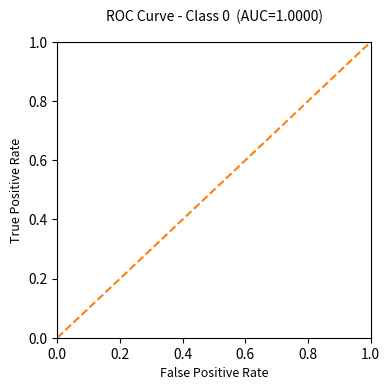

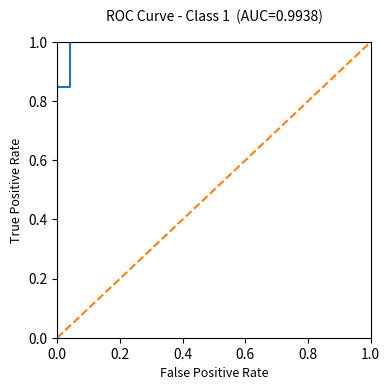

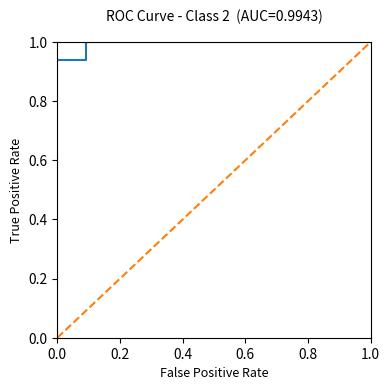

In [59]:
# ==================================================
# 1. 예측 확률
# ==================================================
y_proba = estimator.predict_proba(X_test)
classes = estimator.classes_

# y_test 1차원 배열 정리
y_test_array = np.asarray(y_test).ravel()


# ==================================================
# 2. 클래스별 ROC Curve (OVR)
# ==================================================
for i, cls in enumerate(classes):

    # 해당 클래스 vs 나머지 (One-vs-Rest)
    y_true_binary = (y_test_array == cls).astype(int)
    y_score = y_proba[:, i]

    # ROC 계산
    fpr, tpr, thresholds = roc_curve(y_true_binary, y_score)
    auc_score = roc_auc_score(y_true_binary, y_score)

    # --------------------------------------------------
    # 그래프 출력 (클래스별 개별 출력)
    # --------------------------------------------------
    plt.figure(dpi=100, figsize=(4, 4))

    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle="--")

    plt.xlabel("False Positive Rate", fontsize=9)
    plt.ylabel("True Positive Rate", fontsize=9)

    plt.title(
        f"ROC Curve - Class {cls}  (AUC={auc_score:.4f})",
        fontsize=10,
    )

    plt.xlim(0, 1)
    plt.ylim(0, 1)

    plt.tight_layout()
    plt.show()
